In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

DATA_DIR = '/kaggle/input/competitions/datathon-2026-round-1/'

print("Đã thiết lập xong đường dẫn!")

sns.set_theme(style='whitegrid')
print("200 OK")

def load_and_fix_date(file_name):
    df = pd.read_csv(DATA_DIR + file_name)
    for col in df.columns:
        if any(x in col.lower() for x in ['date', 'day', 'ngày']):
            df = df.rename(columns={col: 'date'})
            break
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    return df

sales = load_and_fix_date('sales.csv')
traffic = load_and_fix_date('web_traffic.csv')
promo = load_and_fix_date('promotions.csv')

print("Đã load và sửa tên cột tự động.")

Đã thiết lập xong đường dẫn!
200 OK
Đã load và sửa tên cột tự động.


C:\Users\nguynlebaodan\AppData\Local\Temp\ipykernel_18444\2025878194.py:2: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  items = pd.read_csv(DATA_DIR + 'order_items.csv')


,Danh mục mặt hàng,Số lượng bị hủy
0,Streetwear,36120
1,Outdoor,23991
2,GenZ,3359
3,Casual,2203


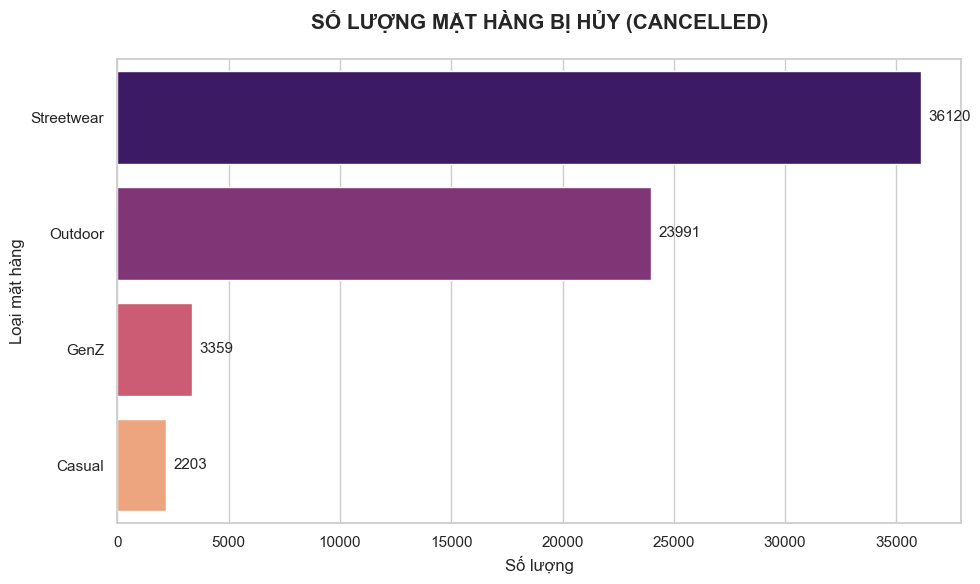

In [14]:
orders = pd.read_csv(DATA_DIR + 'orders.csv')
items = pd.read_csv(DATA_DIR + 'order_items.csv')
products = pd.read_csv(DATA_DIR + 'products.csv')

for df in [orders, items, products]:
    df.columns = df.columns.str.lower().str.strip()

cancelled_orders = orders[orders['order_status'].str.lower() == 'cancelled']

cancelled_items = cancelled_orders.merge(items, on='order_id', how='inner')
cancelled_products = cancelled_items.merge(products, on='product_id', how='left')

cat_col = 'category'

cancel_counts = cancelled_products[cat_col].value_counts().reset_index()
cancel_counts.columns = ['Danh mục mặt hàng', 'Số lượng bị hủy']

display(cancel_counts)

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=cancel_counts, 
                 y='Danh mục mặt hàng', 
                 x='Số lượng bị hủy', 
                 hue='Danh mục mặt hàng',
                 palette='magma', 
                 legend=False)

plt.title('SỐ LƯỢNG MẶT HÀNG BỊ HỦY (CANCELLED)\n', fontsize=15, fontweight='bold')
plt.xlabel('Số lượng', fontsize=12)
plt.ylabel('Loại mặt hàng', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=11)

plt.tight_layout()
plt.show()

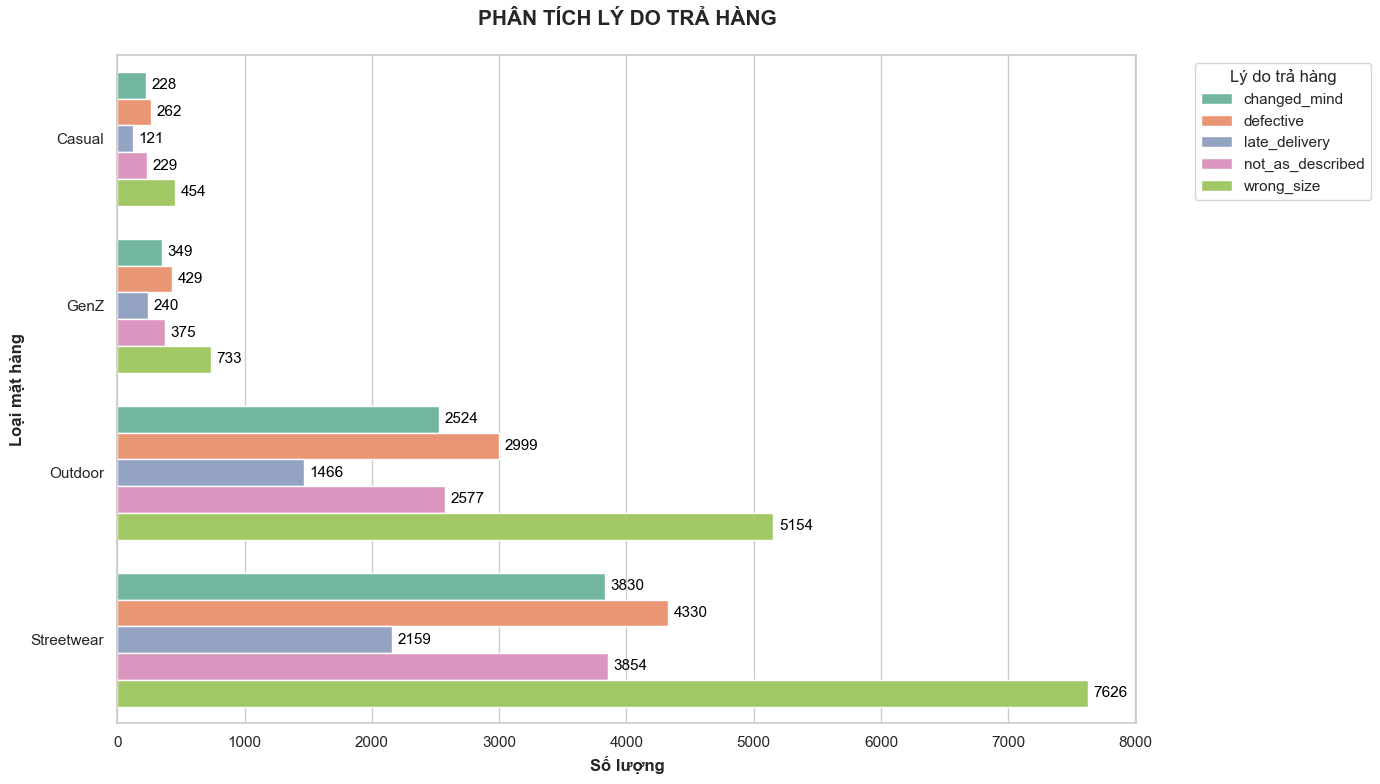

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

returns = pd.read_csv(DATA_DIR + 'returns.csv')
products = pd.read_csv(DATA_DIR + 'products.csv')

returns.columns = returns.columns.str.lower().str.strip()
products.columns = products.columns.str.lower().str.strip()

returned_products = returns.merge(products, on='product_id', how='left')
cat_col = 'category' if 'category' in returned_products.columns else 'segment'

reason_col = None
for col in ['return_reason', 'reason', 'return_type']:
    if col in returned_products.columns:
        reason_col = col
        break

if reason_col:
    top_5_cats = returned_products[cat_col].value_counts().nlargest(5).index
    df_top5 = returned_products[returned_products[cat_col].isin(top_5_cats)]

    reason_counts = df_top5.groupby([cat_col, reason_col]).size().reset_index(name='Số lượng')

    plt.figure(figsize=(14, 8))

    ax = sns.barplot(data=reason_counts, 
                     y=cat_col, 
                     x='Số lượng', 
                     hue=reason_col,
                     palette='Set2') 

    plt.title('PHÂN TÍCH LÝ DO TRẢ HÀNG\n', fontsize=15, fontweight='bold')
    plt.xlabel('Số lượng', fontsize=12, fontweight='bold')
    plt.ylabel('Loại mặt hàng', fontsize=12, fontweight='bold')
    
    plt.legend(title='Lý do trả hàng', bbox_to_anchor=(1.05, 1), loc='upper left')

    for container in ax.containers:
        ax.bar_label(container, fmt='%g', padding=4, fontsize=11, color='black')

    plt.tight_layout()
    plt.show()

else:
    print("Không tìm thấy cột Lý do trả hàng!")

C:\Users\nguynlebaodan\AppData\Local\Temp\ipykernel_18444\2139272521.py:3: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  items = pd.read_csv(DATA_DIR + 'order_items.csv')
C:\Users\nguynlebaodan\AppData\Local\Temp\ipykernel_18444\2139272521.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_top_revenue[cat_col], rotation=0, fontsize=11, fontweight='500')


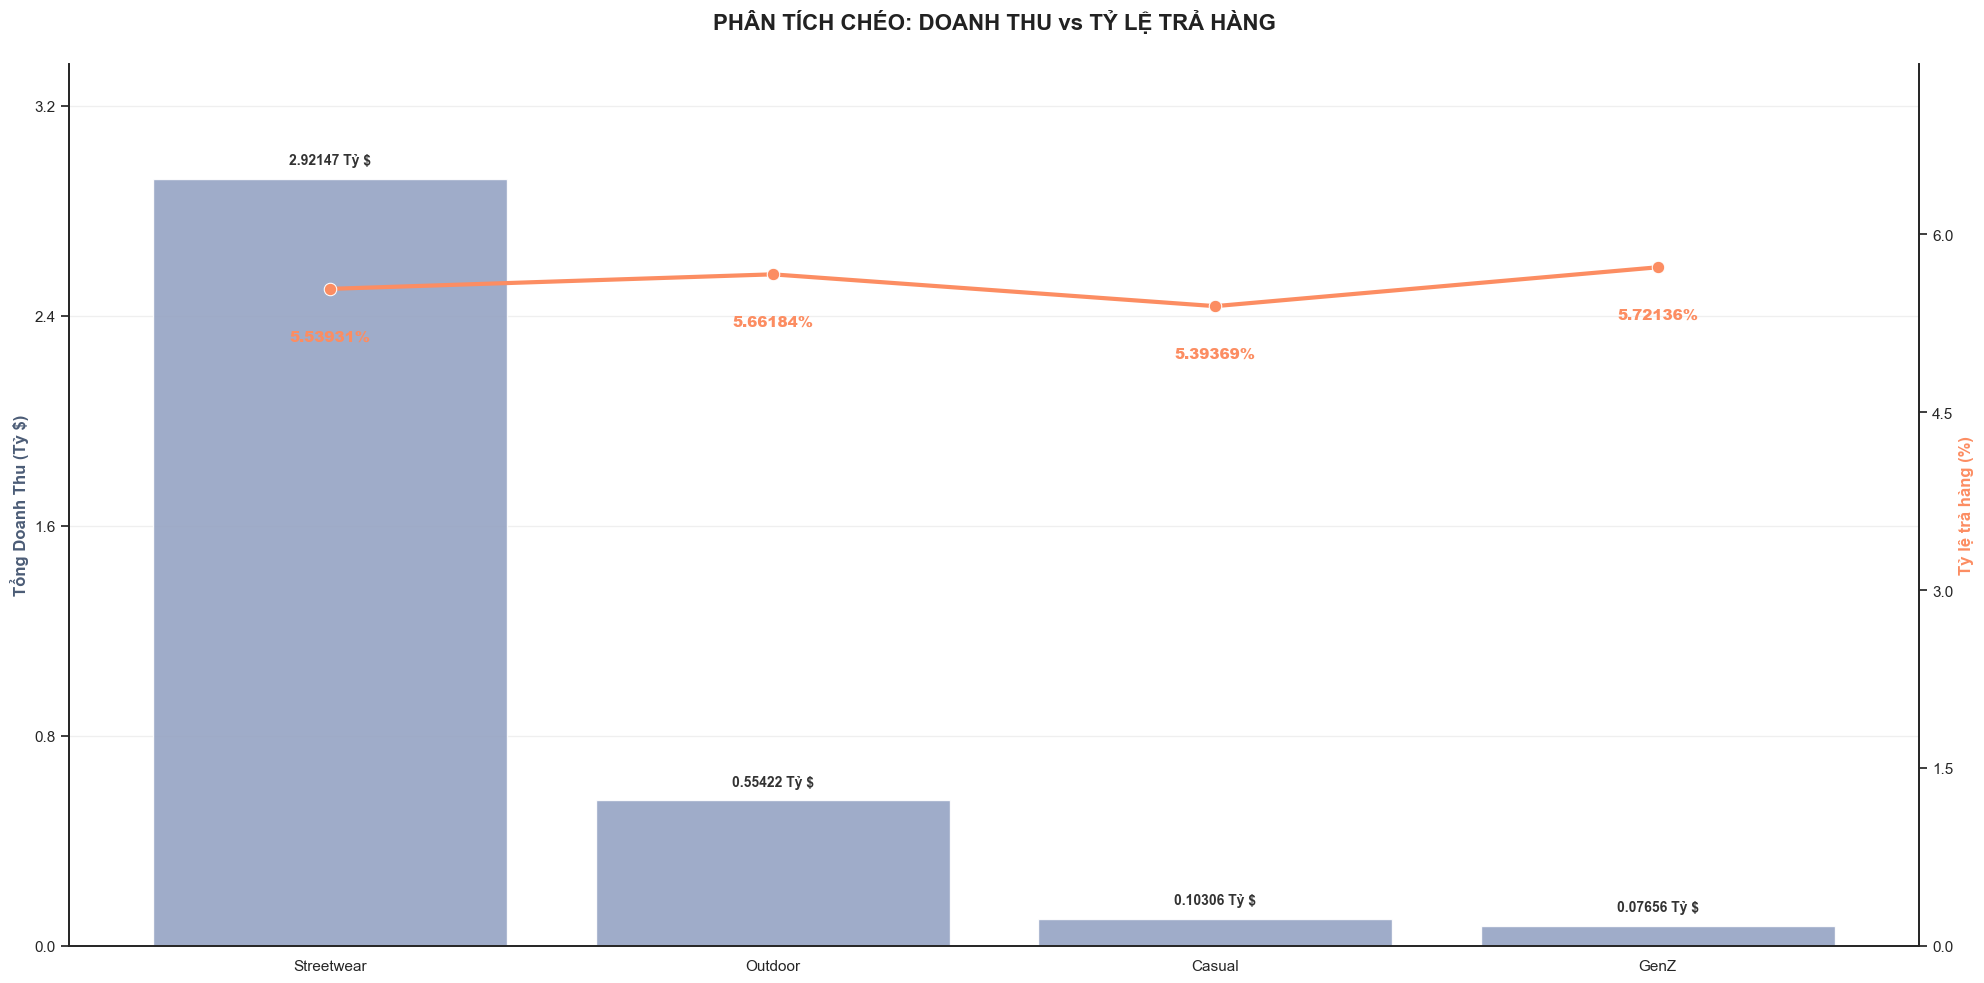

In [16]:
try:
    returns = pd.read_csv(DATA_DIR + 'returns.csv')
    items = pd.read_csv(DATA_DIR + 'order_items.csv')
    products = pd.read_csv(DATA_DIR + 'products.csv')
except FileNotFoundError as e:
    print(f"Lỗi: Không tìm thấy file. Hãy kiểm tra lại DATA_DIR. Chi tiết: {e}")
    raise

for df in [returns, items, products]:
    df.columns = df.columns.str.lower().str.strip()

cat_col = 'category' if 'category' in products.columns else 'segment'
price_col = 'price' if 'price' in items.columns else items.columns[items.columns.str.contains('price|value')][0]

sold_products = items.merge(products, on='product_id', how='left')
sales_stats = sold_products.groupby(cat_col).agg(
    So_luong_BAN=('product_id', 'count'),
    Tong_Doanh_Thu=(price_col, 'sum')
).reset_index()

returned_products = returns.merge(products, on='product_id', how='left')
return_stats = returned_products.groupby(cat_col).size().reset_index(name='So_luong_TRA')

df_insight = sales_stats.merge(return_stats, on=cat_col, how='left').fillna(0)
df_insight['Ty_le_tra_hang (%)'] = (df_insight['So_luong_TRA'] / df_insight['So_luong_BAN']) * 100

df_top_revenue = df_insight[df_insight['So_luong_BAN'] > 10].sort_values(by='Tong_Doanh_Thu', ascending=False).head(10)

sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(20, 10))

color_bar = '#8da0cb'
color_line = '#fc8d62'

sns.barplot(data=df_top_revenue, x=cat_col, y='Tong_Doanh_Thu', ax=ax1, color=color_bar, alpha=0.9)

ax1.set_ylabel('Tổng Doanh Thu (Tỷ $)', fontsize=12, fontweight='bold', color='#4b5c76')
ax1.set_xlabel('')
ax1.set_xticklabels(df_top_revenue[cat_col], rotation=0, fontsize=11, fontweight='500')

def billion_formatter(x, pos):
    return f'{x / 1e9:.1f}'
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(billion_formatter))

max_rev = df_top_revenue['Tong_Doanh_Thu'].max()
ax1.set_ylim(0, max_rev * 1.15) 

for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        label = f"{height / 1e9:.5f} Tỷ $"
        ax1.text(p.get_x() + p.get_width() / 2., height + (max_rev * 0.015),
                 label, ha='center', va='bottom', color='#333333', fontweight='bold', fontsize=10)

ax2 = ax1.twinx()
x_coords = np.arange(len(df_top_revenue))
sns.lineplot(x=x_coords, y=df_top_revenue['Ty_le_tra_hang (%)'].values, ax=ax2, 
             color=color_line, marker='o', linewidth=3, markersize=9)

ax2.set_ylabel('Tỷ lệ trả hàng (%)', fontsize=12, fontweight='bold', color=color_line)

max_rate = df_top_revenue['Ty_le_tra_hang (%)'].max()
ax2.set_ylim(0, max_rate * 1.3)

for i, val in enumerate(df_top_revenue['Ty_le_tra_hang (%)']):
    ax2.text(i, val - (max_rate * 0.06), f'{val:.5f}%', 
             color=color_line, fontweight='900', ha='center', va='top', fontsize=11)

ax1.yaxis.set_major_locator(plt.MaxNLocator(5))
ax2.yaxis.set_major_locator(plt.MaxNLocator(5))
ax1.grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')

plt.title('PHÂN TÍCH CHÉO: DOANH THU vs TỶ LỆ TRẢ HÀNG', 
          fontsize=16, fontweight='bold', pad=25, color='#222222')

sns.despine(right=False, top=True)

plt.tight_layout()
plt.show()